### **CC57 - MACHINE LEARNING - PREPROCESAMIENTO DE DATOS**

**Nombres / Apellidos:**
Rody Sebastian Vilchez Marin

**Código:**
u202216562

---

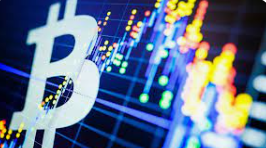

El dataset global de criptomonedas es un conjunto de datos completo  que ofrece una gran cantidad de información sobre más de 7500 criptomonedas, cada una de ellas combinada con el dólar estadounidense (USD). Este conjunto de datos es un recurso invaluable para cualquier persona interesada en explorar el mundo de las monedas digitales y analizar su comportamiento en el mercado. Estos no solo incluyen monedas populares como BTC, ETH y SOL, sino que también capturan monedas recién lanzadas.

**Estructura del Dataset**

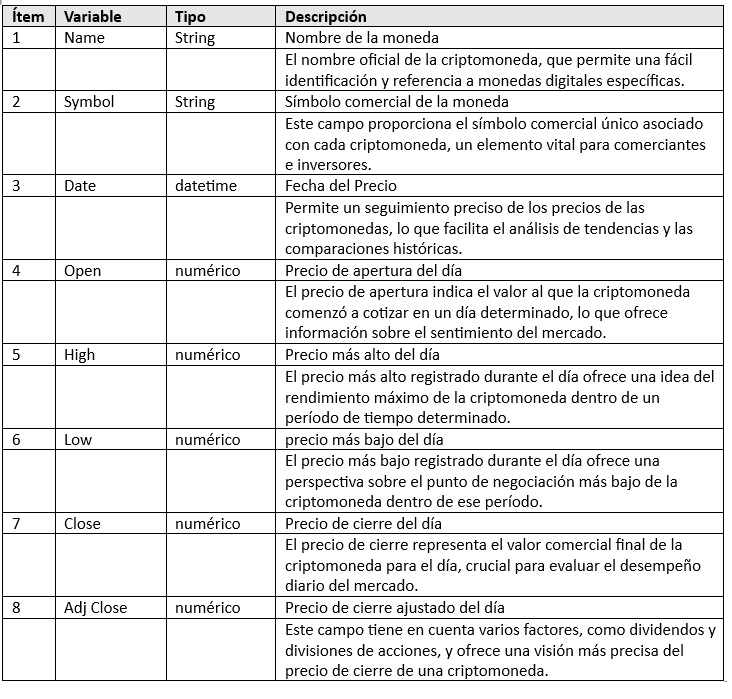

## Desarrollo

### 1) Cargar los datos

In [1]:
!file 01-Ejercicio-Preprocesamiento.zip

01-Ejercicio-Preprocesamiento.zip: Zip archive data, at least v1.0 to extract, compression method=store


In [3]:
!unzip 01-Ejercicio-Preprocesamiento.zip

Archive:  01-Ejercicio-Preprocesamiento.zip
   creating: Ejercicio-Preprocesamiento/
  inflating: Ejercicio-Preprocesamiento/01_ML_Preprocesamiento_CriptoMonedas.ipynb  
   creating: Ejercicio-Preprocesamiento/data/
  inflating: Ejercicio-Preprocesamiento/data/00-USD.csv  
  inflating: Ejercicio-Preprocesamiento/data/0NE-USD.csv  
  inflating: Ejercicio-Preprocesamiento/data/0X0-USD.csv  
  inflating: Ejercicio-Preprocesamiento/data/0XBTC-USD.csv  
  inflating: Ejercicio-Preprocesamiento/data/0XGAS-USD.csv  
  inflating: Ejercicio-Preprocesamiento/data/0XPROOF-USD.csv  
  inflating: Ejercicio-Preprocesamiento/data/0XS-USD.csv  
  inflating: Ejercicio-Preprocesamiento/data/100XGEMS-USD.csv  
  inflating: Ejercicio-Preprocesamiento/data/10SET-USD.csv  
  inflating: Ejercicio-Preprocesamiento/data/128142128588-USD.csv  
  inflating: Ejercicio-Preprocesamiento/data/1ART-USD.csv  
  inflating: Ejercicio-Preprocesamiento/data/1BIT-USD.csv  
  inflating: Ejercicio-Preprocesamiento/data/1COIN-

Reparar el comprimido en caso hubiera error durante la carga y descomprimir

In [4]:
# !zip -FF 01-Ejercicio-Preprocesamiento.zip --out fixed.zip
# !unzip fixed.zip -A

In [ ]:
# !pip install pandas matplotlib seaborn 

### Carga de datos al cuaderno

In [ ]:
import os

folder_path = "Ejercicio-Preprocesamiento/data/."
# listar todos los csv del folder path
csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]
csv_files.__len__()

7537

In [9]:
import pandas as pd
# revisar la metadata
df_metadata = pd.read_csv("Ejercicio-Preprocesamiento/metadata.csv")
df_metadata.head()

,Coin Pair Name,Coin Pair Symbol,File Path
0,Bitcoin USD,BTC-USD,BTC-USD.csv
1,Ethereum USD,ETH-USD,ETH-USD.csv
2,Tether USDt USD,USDT-USD,USDT-USD.csv
3,BNB USD,BNB-USD,BNB-USD.csv
4,USD Coin USD,USDC-USD,USDC-USD.csv


Se realizo la carga de metadatos y lectura de archivos sin problemas
- Se procedera a preprocesar la metadata antes de continuar con la carga de archivos 

## 2) Datos faltantes y duplicados


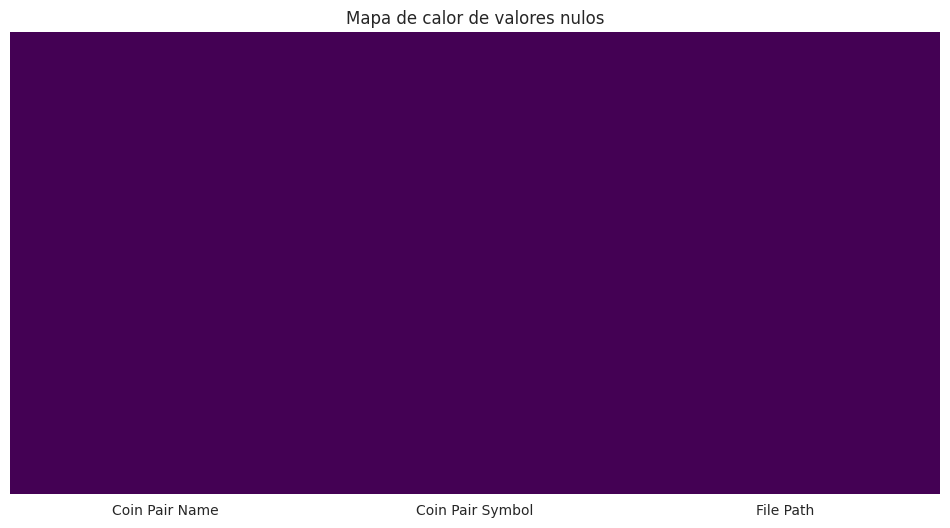

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6))
sns.heatmap(df_metadata.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Mapa de calor de valores nulos')
plt.show()


In [ ]:
def verificar_archivos_perdidos(df_metadata, data_files):
  if len(data_files) == df_metadata.shape[0]:
    print("Los archivos coinciden con la metadata")
  else:
    print("Los archivos no coinciden con la metadata")
    print(f"{df_metadata.shape[0] - len(data_files)} archivos faltantes con respecto a la metadata")

verificar_archivos_perdidos(df_metadata, csv_files)

Los archivos no coinciden con la metadata
3766 archivos faltantes con respecto a la metadata


### 2.1 Datos faltantes

La metadata no es consistente con los data asociada, se realizara una exploracion para determinar la causa


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

metadata_files = set(df_metadata['File Path'])
directory_files = set(csv_files)

faltan_en_directorio = metadata_files - directory_files
sobran_en_directorio = directory_files - metadata_files

print("Faltan en directorio:", len(faltan_en_directorio))
print("Sobran en directorio:", len(sobran_en_directorio))


Faltan en directorio: 0
Sobran en directorio: 0


2.1 Parece que no faltan datos, se atribuye a que el set solo toma una unica incidencia.

**Criterio:** Mayor cantidad de registros en metadata, al comparar registros unicos no se muestran diferencias.

**Se determina:** Duplicados en metadata

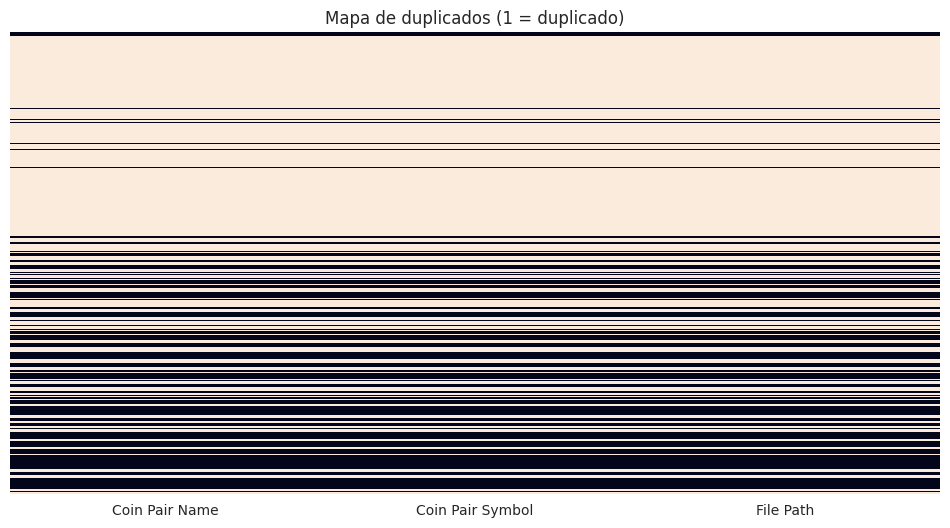

In [ ]:
# Crear una máscara booleana para duplicados
duplicados = df_metadata.duplicated(keep=False)
# Expandir eso al DataFrame
binary_mask = pd.DataFrame(
    np.tile(duplicados.values[:, None], (1, df_metadata.shape[1])),
    columns=df_metadata.columns
)

plt.figure(figsize=(12, 6))
sns.heatmap(binary_mask, cmap='rocket', cbar=False, yticklabels=False)
plt.title('Mapa de duplicados (1 = duplicado)')
plt.show()


Se verifican duplicados.

In [36]:
def verificar_archivos_perdidos(df_metadata, data_files, duplicados):
  n_datos_metadata_sin_duplicados = df_metadata.shape[0] - duplicados
  if len(data_files) == n_datos_metadata_sin_duplicados:
    print("Los archivos coinciden con la metadata")
  else:
    print("Los archivos no coinciden con la metadata")
    print(f"{n_datos_metadata_sin_duplicados - len(data_files)} archivos faltantes con respecto a la metadata sin duplicados")

duplicados_totales = int(df_metadata.duplicated().sum())
verificar_archivos_perdidos(df_metadata, csv_files, duplicados_totales)


Los archivos coinciden con la metadata


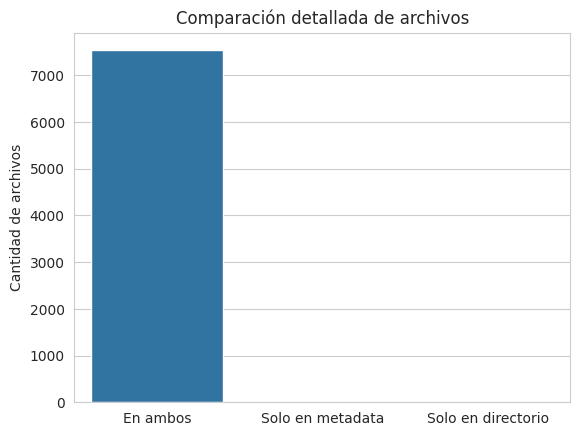

In [38]:
conteo = {
    'En ambos': len(metadata_files & directory_files),
    'Solo en metadata': len(faltan_en_directorio),
    'Solo en directorio': len(sobran_en_directorio)
}

sns.barplot(x=list(conteo.keys()), y=list(conteo.values()))
plt.title('Comparación detallada de archivos')
plt.ylabel('Cantidad de archivos')
plt.show()


In [39]:
# guardar
df_metadata.to_csv("Ejercicio-Preprocesamiento/clean_metadata.csv", index=False)

## EDA

In [40]:
df = pd.read_csv("Ejercicio-Preprocesamiento/clean_metadata.csv")
df.head()

,Coin Pair Name,Coin Pair Symbol,File Path
0,Bitcoin USD,BTC-USD,BTC-USD.csv
1,Ethereum USD,ETH-USD,ETH-USD.csv
2,Tether USDt USD,USDT-USD,USDT-USD.csv
3,BNB USD,BNB-USD,BNB-USD.csv
4,USD Coin USD,USDC-USD,USDC-USD.csv


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11303 entries, 0 to 11302
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Coin Pair Name    11303 non-null  object
 1   Coin Pair Symbol  11303 non-null  object
 2   File Path         11303 non-null  object
dtypes: object(3)
memory usage: 265.0+ KB


## Archivos individuales

Enriquecimiento de la metadata

In [42]:
import pandas as pd
import os

# Función para extraer información, con manejo de EmptyDataError
def extract_info(file_path):
    full_path = os.path.join("Ejercicio-Preprocesamiento/data", file_path)
    try:
        df_file = pd.read_csv(full_path)
        return str(df_file.columns.tolist()), df_file.shape[0]
    except pd.errors.EmptyDataError:  # Captura el EmptyDataError
        print(f"El archivo {file_path} está vacío o no tiene encabezados.")
        return "[]", 0  # Devuelve lista vacía y 0 registros para archivos vacíos
    except Exception as e:
        return str(e), 0  # Manejo de otros errores


# Aplicar la función a cada fila usando apply()
df[['Headers', 'Registros']] = df['File Path'].apply(lambda x: pd.Series(extract_info(x)))

# Mostrar resultado
df.head()

,Coin Pair Name,Coin Pair Symbol,File Path,Headers,Registros
0,Bitcoin USD,BTC-USD,BTC-USD.csv,"['Name', 'Symbol', 'Date', 'Open', 'High', 'Lo...",3325
1,Ethereum USD,ETH-USD,ETH-USD.csv,"['Name', 'Symbol', 'Date', 'Open', 'High', 'Lo...",2176
2,Tether USDt USD,USDT-USD,USDT-USD.csv,"['Name', 'Symbol', 'Date', 'Open', 'High', 'Lo...",2176
3,BNB USD,BNB-USD,BNB-USD.csv,"['Name', 'Symbol', 'Date', 'Open', 'High', 'Lo...",2176
4,USD Coin USD,USDC-USD,USDC-USD.csv,"['Name', 'Symbol', 'Date', 'Open', 'High', 'Lo...",1843


In [43]:
# identificar cuantos valores distintos hay en los headers

print(f"{df['Headers'].unique().__len__()} encabezados unicos")

1 encabezados unicos
